In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load once
df = pd.read_csv("Indian_Kids_Screen_Time.csv")

# Standardize columns ONCE
df.columns = df.columns.str.lower()

# Basic cleaning
df = df.drop_duplicates()
df = df.dropna(how='all')
df = df.ffill()

print("Shape:", df.shape)
print("Columns:", df.columns)

Shape: (9668, 8)
Columns: Index(['age', 'gender', 'avg_daily_screen_time_hr', 'primary_device',
       'exceeded_recommended_limit', 'educational_to_recreational_ratio',
       'health_impacts', 'urban_or_rural'],
      dtype='object')


In [3]:
df.shape
df.columns
df.info()
df.describe()   

<class 'pandas.core.frame.DataFrame'>
Index: 9668 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   age                                9668 non-null   int64  
 1   gender                             9668 non-null   object 
 2   avg_daily_screen_time_hr           9668 non-null   float64
 3   primary_device                     9668 non-null   object 
 4   exceeded_recommended_limit         9668 non-null   bool   
 5   educational_to_recreational_ratio  9668 non-null   float64
 6   health_impacts                     9668 non-null   object 
 7   urban_or_rural                     9668 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 613.7+ KB


,age,avg_daily_screen_time_hr,educational_to_recreational_ratio
count,9668.000000,9668.000000,9668.000000
mean,12.992760,4.367780,0.427028
std,3.158931,1.703002,0.073185
min,8.000000,0.000000,0.300000
25%,10.000000,3.427500,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [4]:
df.duplicated().sum()
df.drop_duplicates(inplace=True) 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9668 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   age                                9668 non-null   int64  
 1   gender                             9668 non-null   object 
 2   avg_daily_screen_time_hr           9668 non-null   float64
 3   primary_device                     9668 non-null   object 
 4   exceeded_recommended_limit         9668 non-null   bool   
 5   educational_to_recreational_ratio  9668 non-null   float64
 6   health_impacts                     9668 non-null   object 
 7   urban_or_rural                     9668 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 613.7+ KB


In [6]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
) 
df.head()

,age,gender,avg_daily_screen_time_hr,primary_device,exceeded_recommended_limit,educational_to_recreational_ratio,health_impacts,urban_or_rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,Poor Sleep,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [7]:
df.shape

(9668, 8)

In [8]:
df['health_impacts'].isnull().sum()

np.int64(0)

In [9]:
df.columns

Index(['age', 'gender', 'avg_daily_screen_time_hr', 'primary_device',
       'exceeded_recommended_limit', 'educational_to_recreational_ratio',
       'health_impacts', 'urban_or_rural'],
      dtype='object')

In [10]:
df.describe()

,age,avg_daily_screen_time_hr,educational_to_recreational_ratio
count,9668.000000,9668.000000,9668.000000
mean,12.992760,4.367780,0.427028
std,3.158931,1.703002,0.073185
min,8.000000,0.000000,0.300000
25%,10.000000,3.427500,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [11]:
df.isnull().sum()

age                                  0
gender                               0
avg_daily_screen_time_hr             0
primary_device                       0
exceeded_recommended_limit           0
educational_to_recreational_ratio    0
health_impacts                       0
urban_or_rural                       0
dtype: int64

In [12]:
df['health_impacts'] = df['health_impacts'].fillna("No Health Impact")

In [13]:
df['health_impacts'].isnull().sum()

np.int64(0)

In [14]:
# Handle missing values first
df['health_impacts'] = df['health_impacts'].fillna('Unknown')

# Split multiple impacts
df['health_impacts_list'] = df['health_impacts'].str.split(',')

# Explode into separate rows
df_exploded = df.explode('health_impacts_list')

# Remove extra spaces
df_exploded['health_impacts_list'] = df_exploded['health_impacts_list'].str.strip()

print("Exploded dataset shape:", df_exploded.shape)

Exploded dataset shape: (15016, 9)


In [15]:
# First, check if the column exists, if not create it
if 'health_impacts' not in df.columns:
    # You might need to create the column or check if it has a different name
    # Option 1: Create empty column
    df['health_impacts'] = ''
    # Option 2: Rename an existing column (uncomment if needed)
    # df.rename(columns={'actual_column_name': 'health_impacts'}, inplace=True)

# Handle missing values
df['health_impacts'] = df['health_impacts'].fillna('Unknown')

# Split multiple impacts
df['health_impacts_list'] = df['health_impacts'].str.split(',')

# Explode into separate rows
df_exploded = df.explode('health_impacts_list')

# Remove extra spaces
df_exploded['health_impacts_list'] = df_exploded['health_impacts_list'].str.strip()

print("Exploded dataset shape:", df_exploded.shape)

Exploded dataset shape: (15016, 9)


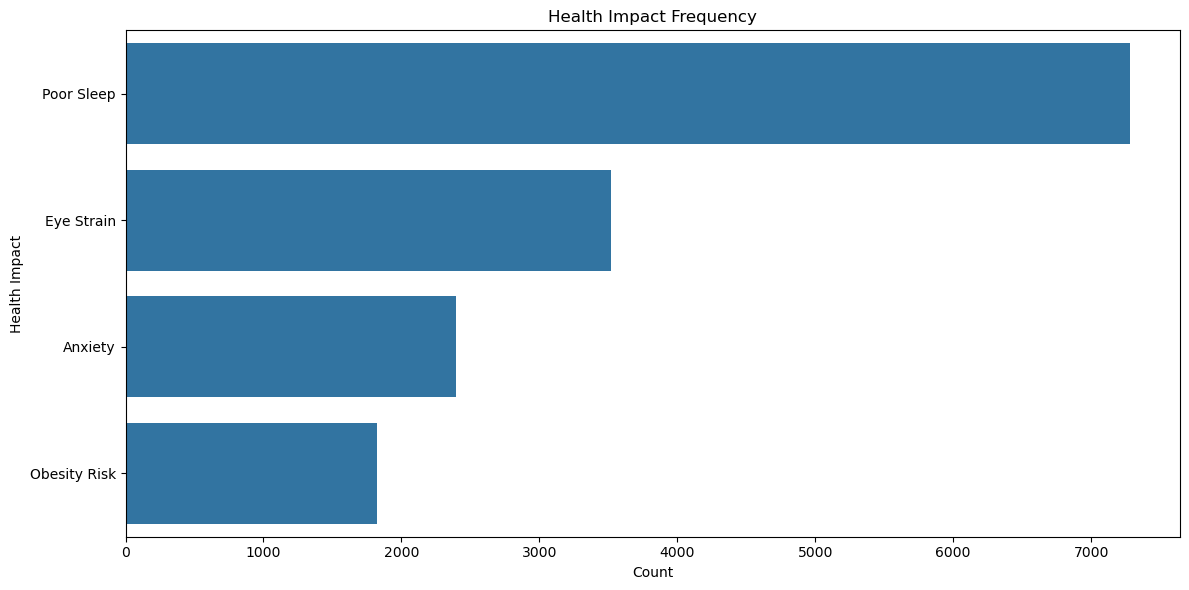

In [16]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df_exploded,
    y='health_impacts_list',
    order=df_exploded['health_impacts_list'].value_counts().index
)

plt.title("Health Impact Frequency")
plt.xlabel("Count")
plt.ylabel("Health Impact")

plt.tight_layout()
plt.show()

In [17]:
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col) 

In [18]:
bins = [0,5,10,15,18]
labels = ['toddler','child','pre-teen','teen']

df['age_band'] = pd.cut(df['age'], bins=bins, labels=labels)

In [19]:
bins = [5,10,13,16,18]
labels = ["6-10","11-13","14-16","17-18"]

df["Age_Band"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

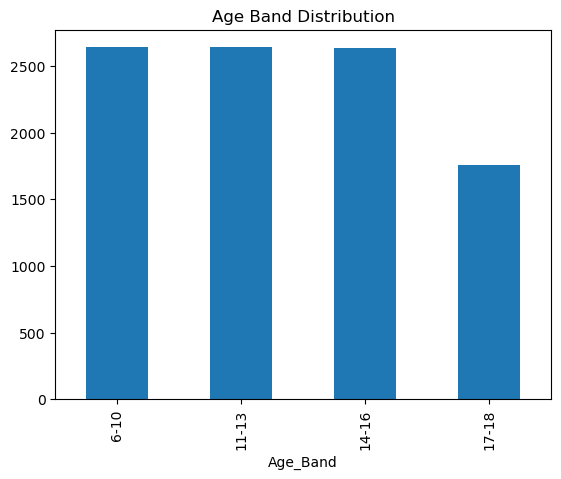

In [20]:
import matplotlib.pyplot as plt

plt.figure()
df["Age_Band"].value_counts().sort_index().plot(kind="bar")
plt.title("Age Band Distribution")
plt.show()

In [21]:
df["Day_Type"] = df["avg_daily_screen_time_hr"].apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

In [22]:
df['day_type'] = np.where(df['avg_daily_screen_time_hr']>4,'Weekend','Weekday')

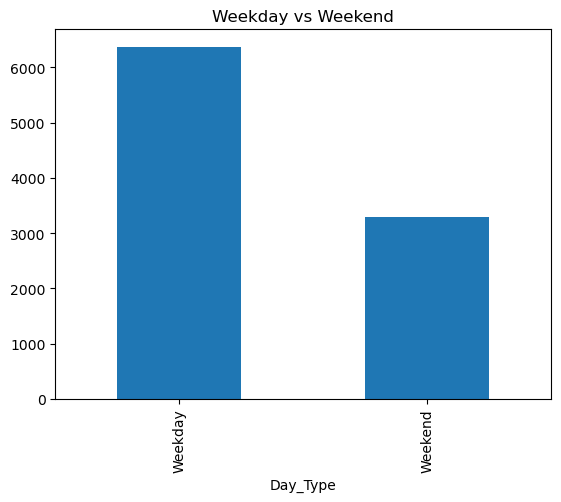

In [23]:
plt.figure()
df["Day_Type"].value_counts().plot(kind="bar")
plt.title("Weekday vs Weekend")
plt.show()

In [24]:
device_share = df['primary_device'].value_counts(normalize=True)

device_share

primary_device
Smartphone    0.469590
TV            0.256309
Laptop        0.148014
Tablet        0.126086
Name: proportion, dtype: float64

In [25]:
df['device_share'] = df['primary_device'].map(device_share)

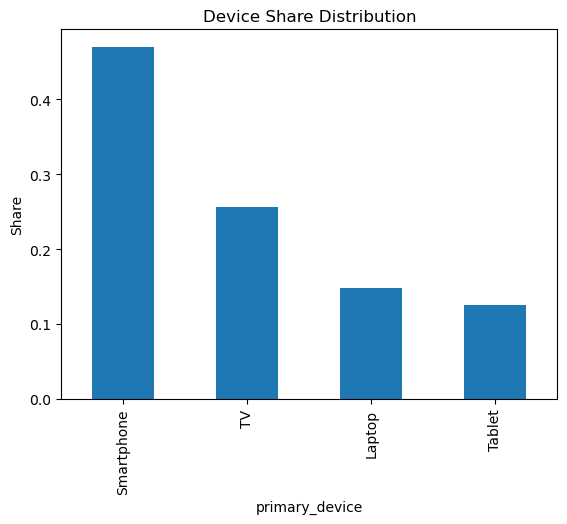

In [26]:
device_share.plot(kind='bar')
plt.title("Device Share Distribution")
plt.ylabel("Share")
plt.show()

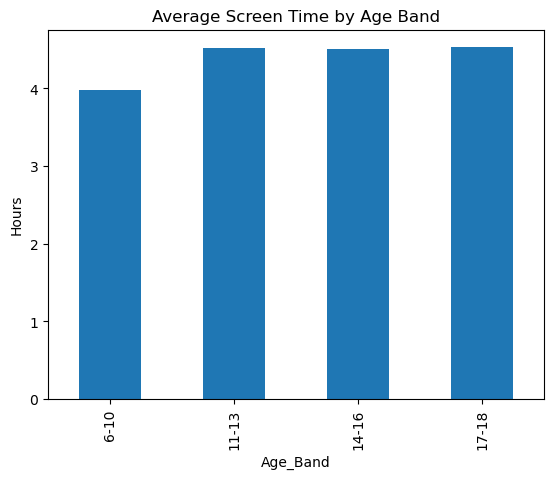

In [27]:
plt.figure()

df.groupby("Age_Band", observed=False)["avg_daily_screen_time_hr"].mean().plot(kind="bar")

plt.title("Average Screen Time by Age Band")
plt.ylabel("Hours")
plt.show()

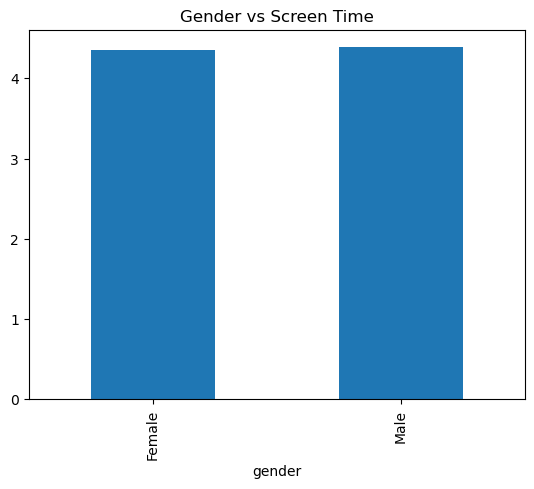

In [28]:
plt.figure()
df.groupby("gender")["avg_daily_screen_time_hr"].mean().plot(kind="bar")
plt.title("Gender vs Screen Time")
plt.show()

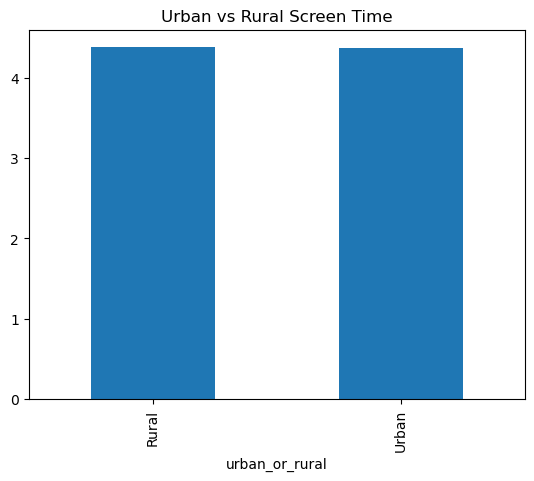

In [29]:
plt.figure()
df.groupby("urban_or_rural")["avg_daily_screen_time_hr"].mean().plot(kind="bar")
plt.title("Urban vs Rural Screen Time")
plt.show()

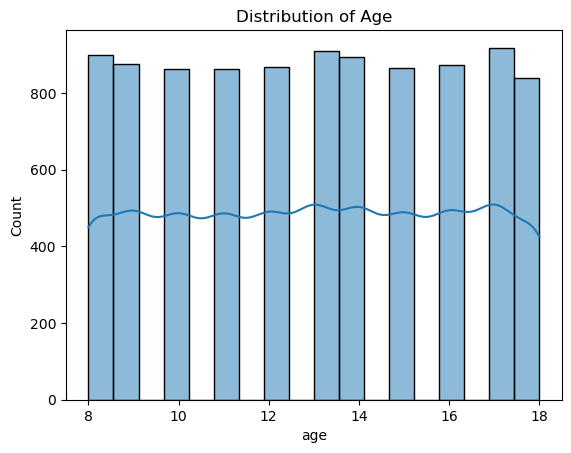

In [30]:
plt.figure()
sns.histplot(df['age'], kde=True)
plt.title("Distribution of Age")
plt.show()

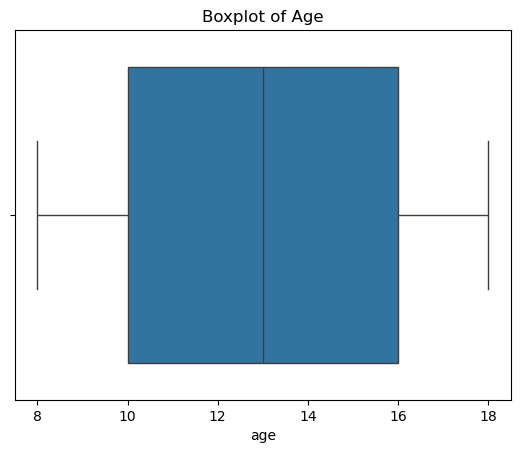

In [31]:
plt.figure()
sns.boxplot(x=df['age'])
plt.title("Boxplot of Age")
plt.show()

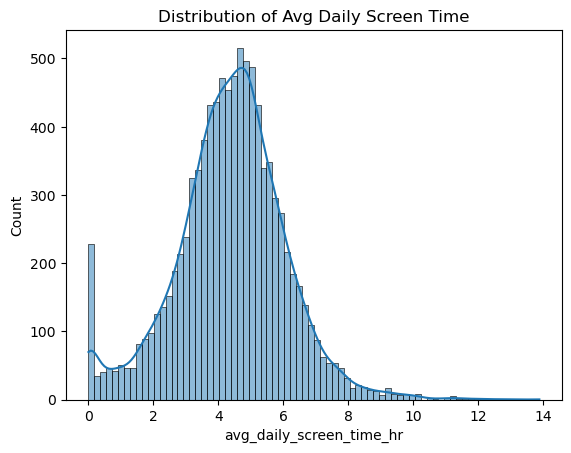

In [32]:
plt.figure()
sns.histplot(df['avg_daily_screen_time_hr'], kde=True)
plt.title("Distribution of Avg Daily Screen Time")
plt.show()

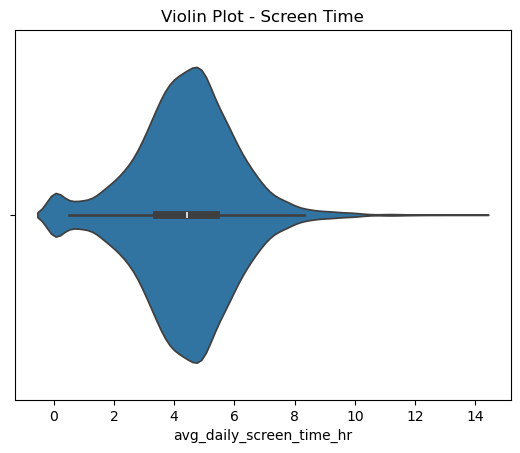

In [33]:
plt.figure()
sns.violinplot(x=df['avg_daily_screen_time_hr'])
plt.title("Violin Plot - Screen Time")
plt.show()

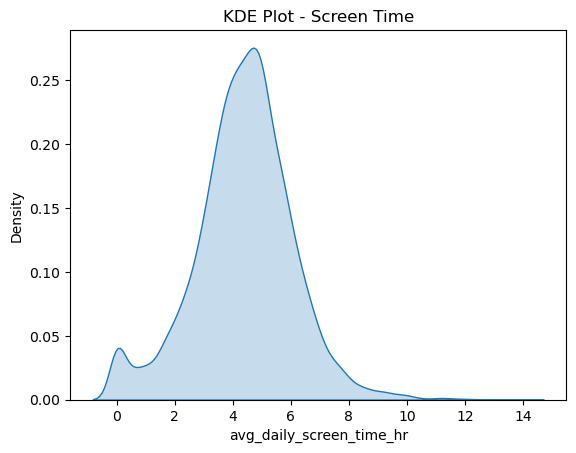

In [34]:
plt.figure()
sns.kdeplot(df['avg_daily_screen_time_hr'], fill=True)
plt.title("KDE Plot - Screen Time")
plt.show()

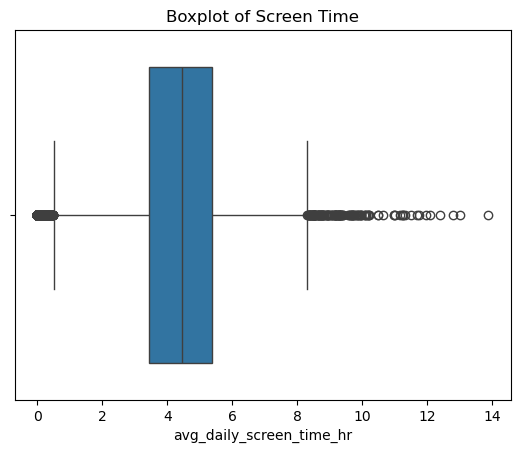

In [35]:
plt.figure()
sns.boxplot(x=df['avg_daily_screen_time_hr'])
plt.title("Boxplot of Screen Time")
plt.show()

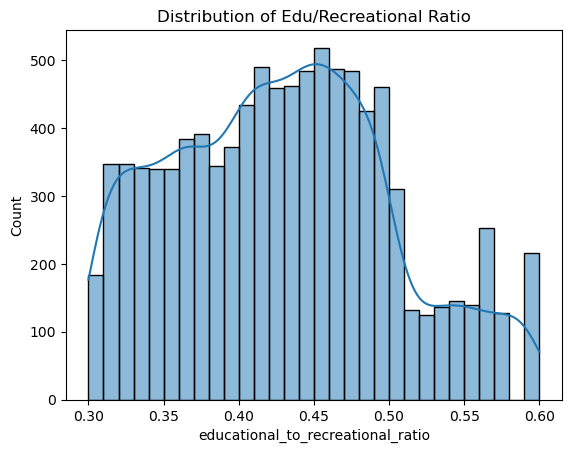

In [36]:
plt.figure()
sns.histplot(df['educational_to_recreational_ratio'], kde=True)
plt.title("Distribution of Edu/Recreational Ratio")
plt.show()

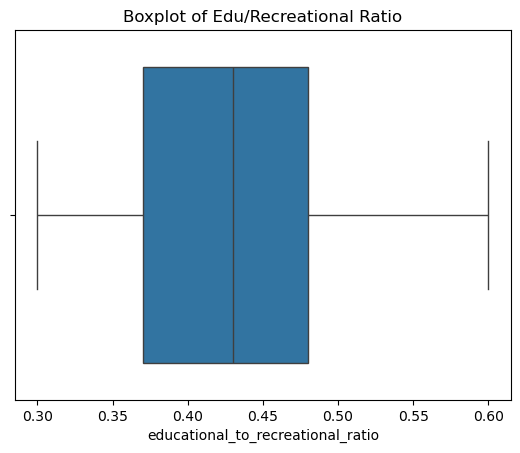

In [37]:
plt.figure()
sns.boxplot(x=df['educational_to_recreational_ratio'])
plt.title("Boxplot of Edu/Recreational Ratio")
plt.show()

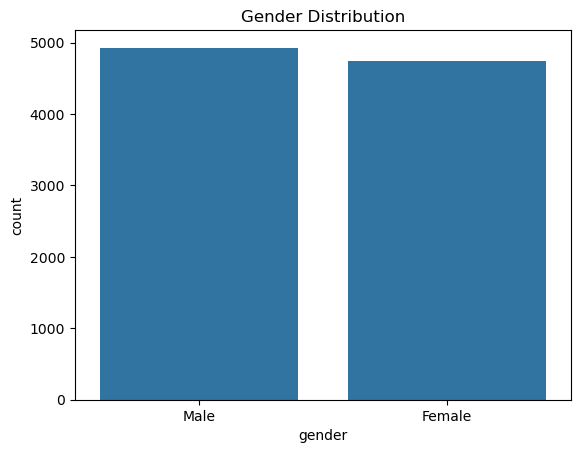

In [38]:
plt.figure()
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

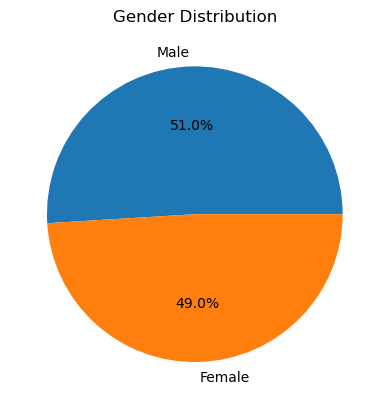

In [39]:
plt.figure()
df['gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel('')
plt.show()

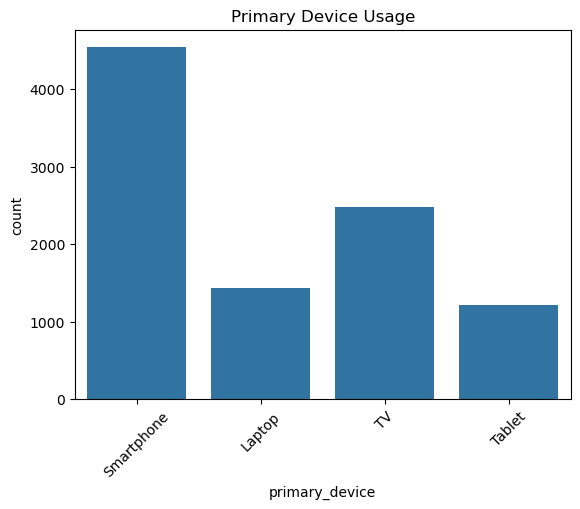

In [40]:
plt.figure()
sns.countplot(x='primary_device', data=df)
plt.xticks(rotation=45)
plt.title("Primary Device Usage")
plt.show()

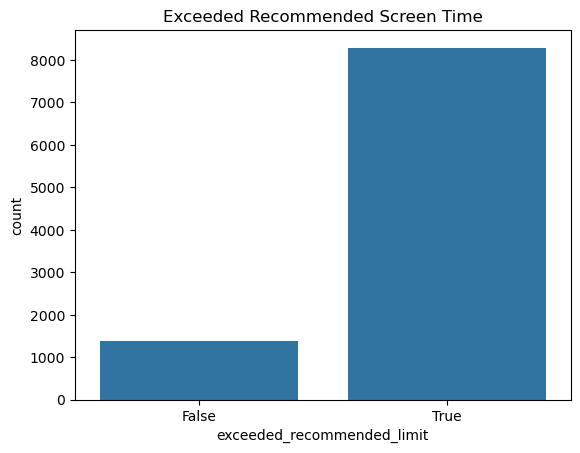

In [41]:
plt.figure()
sns.countplot(x='exceeded_recommended_limit', data=df)
plt.title("Exceeded Recommended Screen Time")
plt.show()

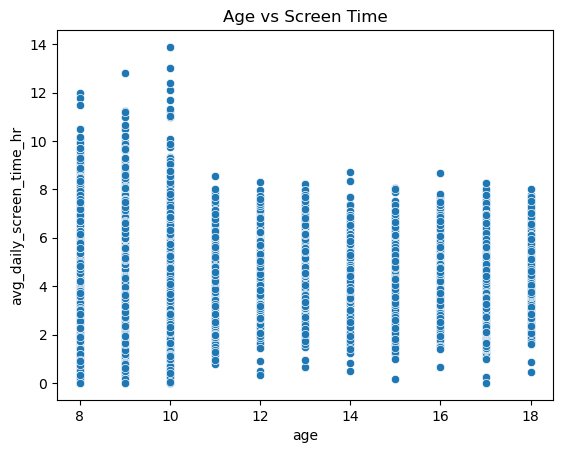

In [42]:
plt.figure()
sns.scatterplot(x='age', y='avg_daily_screen_time_hr', data=df)
plt.title("Age vs Screen Time")
plt.show()

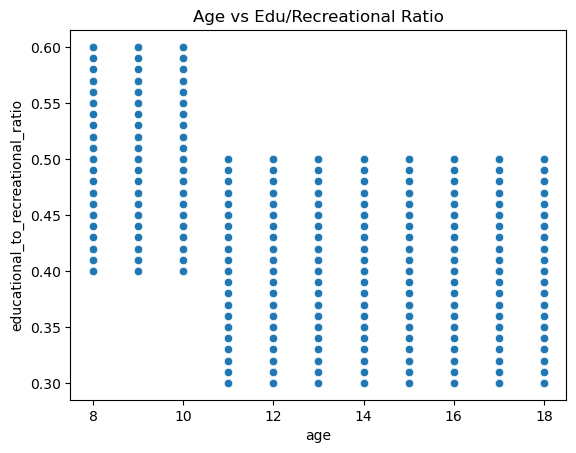

In [43]:
plt.figure()
sns.scatterplot(x='age', y='educational_to_recreational_ratio', data=df)
plt.title("Age vs Edu/Recreational Ratio")
plt.show()

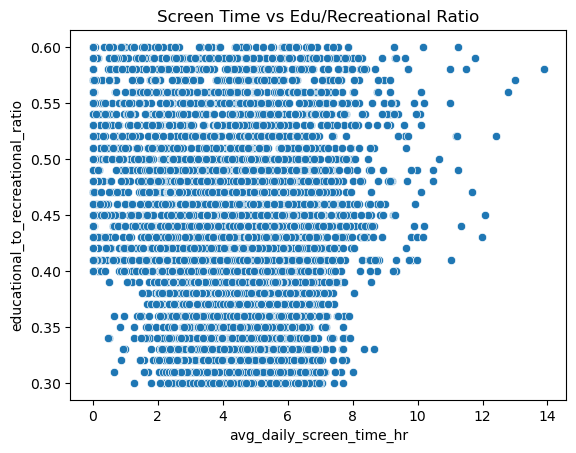

In [44]:
plt.figure()
sns.scatterplot(x='avg_daily_screen_time_hr',
                y='educational_to_recreational_ratio',
                data=df)
plt.title("Screen Time vs Edu/Recreational Ratio")
plt.show()

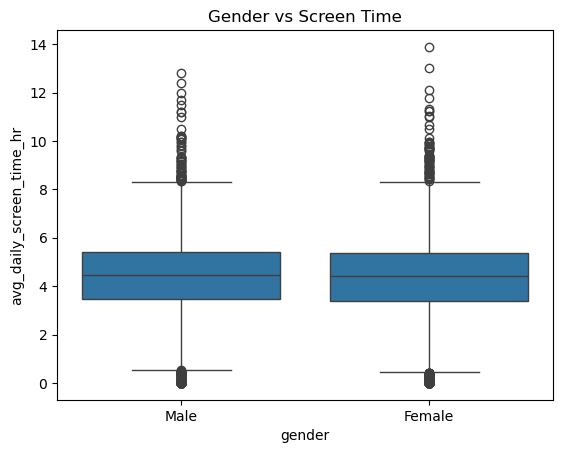

In [45]:
plt.figure()
sns.boxplot(x='gender', y='avg_daily_screen_time_hr', data=df)
plt.title("Gender vs Screen Time")
plt.show()

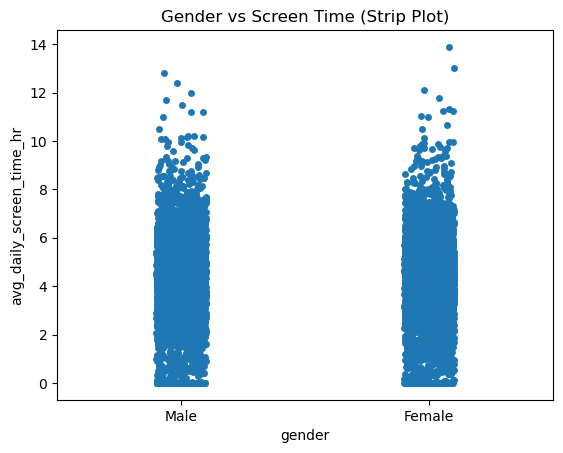

In [46]:
plt.figure()
sns.stripplot(x='gender',
              y='avg_daily_screen_time_hr',
              data=df)
plt.title("Gender vs Screen Time (Strip Plot)")
plt.show()

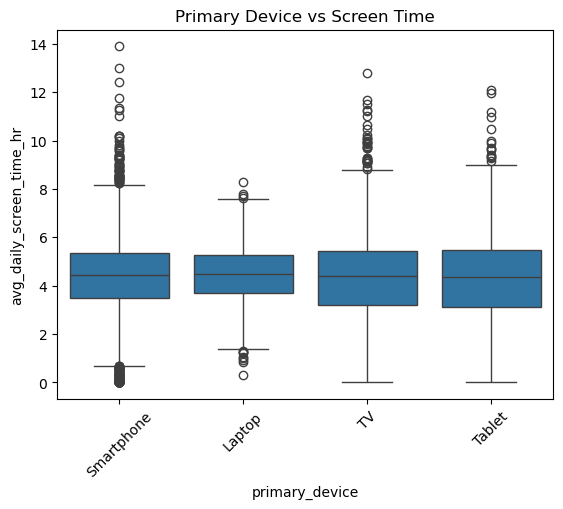

In [47]:
plt.figure()
sns.boxplot(x='primary_device', y='avg_daily_screen_time_hr', data=df)
plt.xticks(rotation=45)
plt.title("Primary Device vs Screen Time")
plt.show()

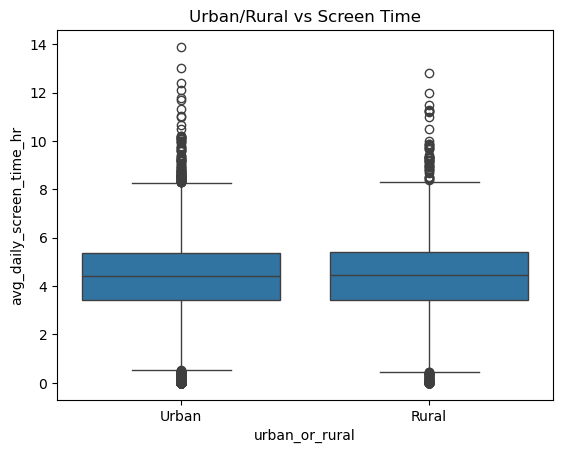

In [48]:
plt.figure()
sns.boxplot(x='urban_or_rural', y='avg_daily_screen_time_hr', data=df)
plt.title("Urban/Rural vs Screen Time")
plt.show()

In [49]:
import pandas as pd

# Create or load a DataFrame first
# Example: Create a sample DataFrame with a timestamp column
df = pd.DataFrame({
    'timestamp': ['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05', '2023-01-06', '2023-01-07'],
    'value': [10, 20, 30, 40, 50, 60, 70]
})

# Now we can convert the timestamp column
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract day of week
df['day_of_week'] = df['timestamp'].dt.day_name()

# Create weekend flag
df['weekend_flag'] = df['day_of_week'].isin(['Saturday','Sunday']).map({True:'Weekend', False:'Weekday'})

# Display the result
print(df)

   timestamp  value day_of_week weekend_flag
0 2023-01-01     10      Sunday      Weekend
1 2023-01-02     20      Monday      Weekday
2 2023-01-03     30     Tuesday      Weekday
3 2023-01-04     40   Wednesday      Weekday
4 2023-01-05     50    Thursday      Weekday
5 2023-01-06     60      Friday      Weekday
6 2023-01-07     70    Saturday      Weekend


In [50]:

data = {
    'Primary_Device': ['Mobile', 'TV', 'Laptop', 'Desktop', 'Tablet']
}
df = pd.DataFrame(data)

portable_devices = ['Mobile', 'Tablet', 'Laptop']
wall_mounted_devices = ['TV', 'Desktop']

df['Device_Category'] = df['Primary_Device'].apply(
    lambda x: 'Portable' if x in portable_devices else 'WallMounted'
)

df[['Primary_Device', 'Device_Category']].head()

,Primary_Device,Device_Category
0,Mobile,Portable
1,TV,WallMounted
2,Laptop,Portable
3,Desktop,WallMounted
4,Tablet,Portable


In [51]:
import pandas as pd
data = {
    'Activity': ['Online Classes', 'Gaming', 'Homework', 'YouTube', 'Social Media']
    
}
df = pd.DataFrame(data)
educational_activities = ['Online Classes', 'Homework', 'Learning Apps']
recreational_activities = ['Gaming', 'YouTube', 'Social Media', 'Entertainment']

df['Activity_Type'] = df['Activity'].apply(
    lambda x: 'Educational' if x in educational_activities else 'Recreational'
)

df[['Activity', 'Activity_Type']].head()

,Activity,Activity_Type
0,Online Classes,Educational
1,Gaming,Recreational
2,Homework,Educational
3,YouTube,Recreational
4,Social Media,Recreational


In [52]:
activity_ratio = (
    df['Activity_Type']
    .value_counts(normalize=True)
    .rename('ratio')
    .reset_index()
)

activity_ratio

,Activity_Type,ratio
0,Recreational,0.6
1,Educational,0.4


Shape: (9712, 8)
Columns: Index(['age', 'gender', 'avg_daily_screen_time_hr', 'primary_device',
       'exceeded_recommended_limit', 'educational_to_recreational_ratio',
       'health_impacts', 'urban_or_rural'],
      dtype='object')

Derived Columns Added Successfully!
  age_band education_category           device_type
0    14-16  More Recreational              Portable
1    11-13  More Recreational              Portable
2    17-18  More Recreational  Wall Mounted / Other
3    14-16  More Recreational              Portable
4    11-13  More Recreational              Portable


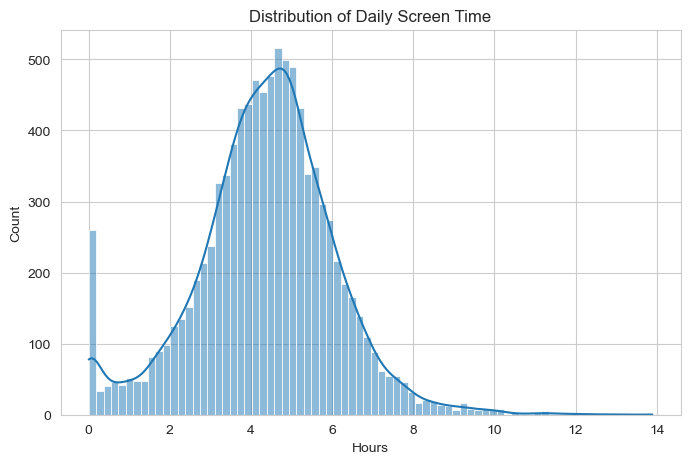

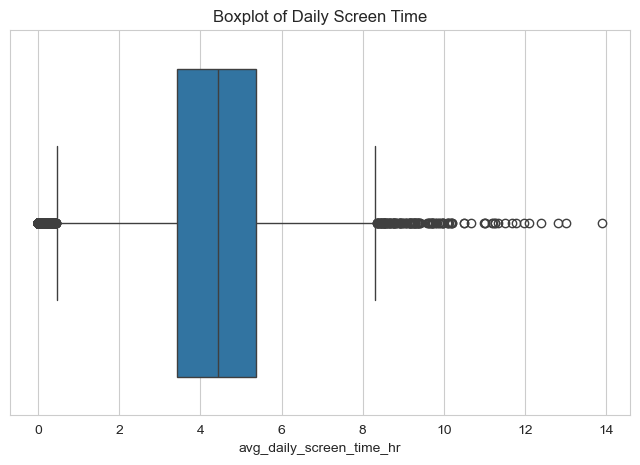

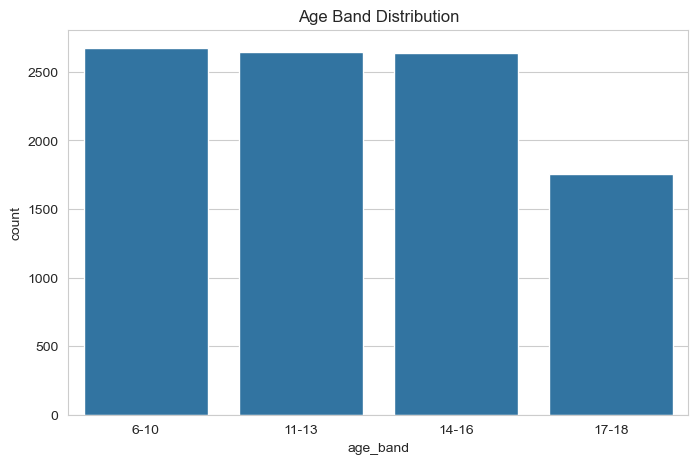

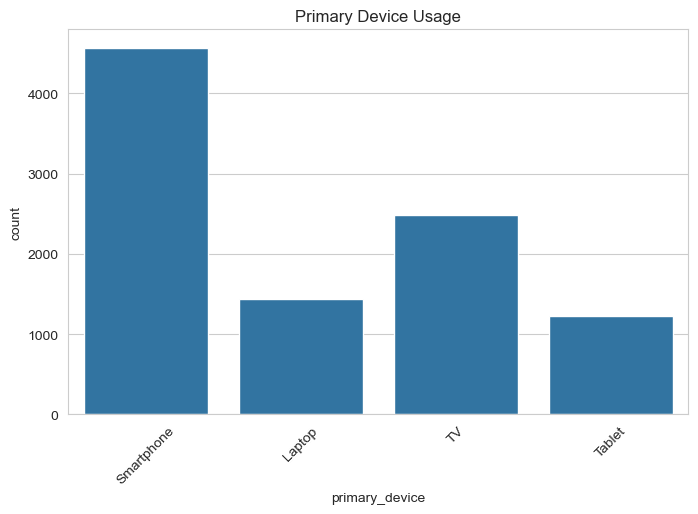

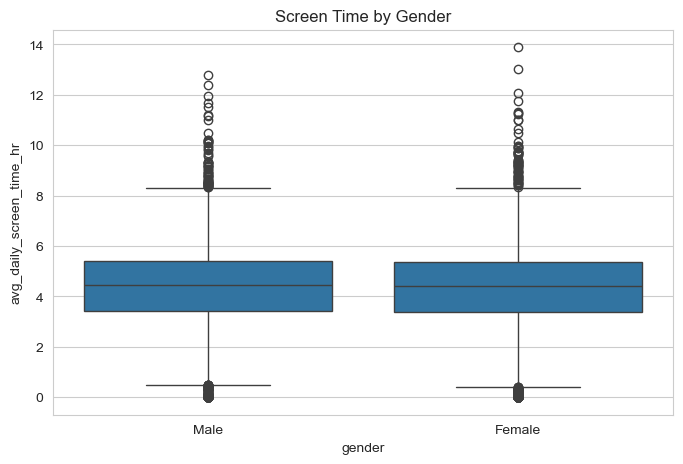

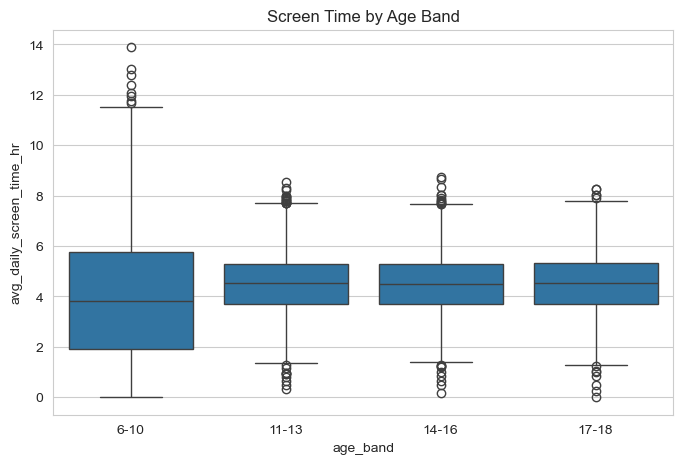

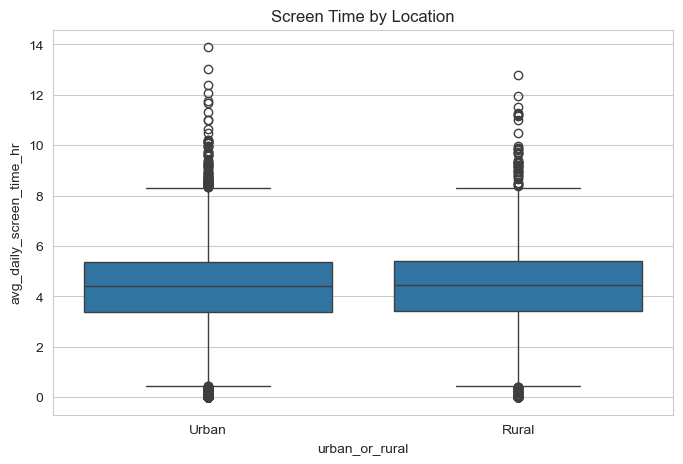

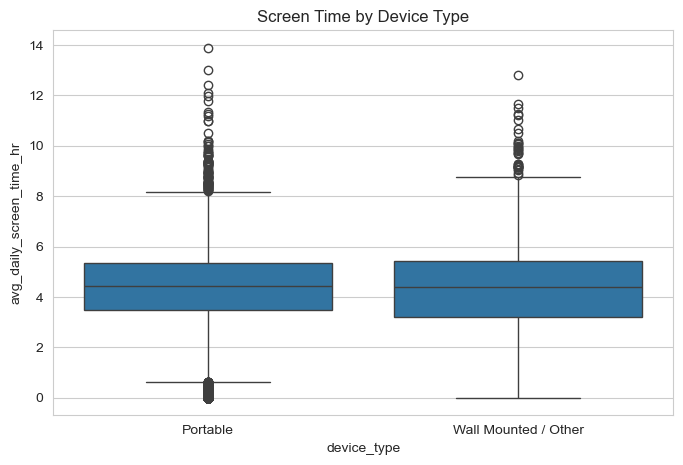

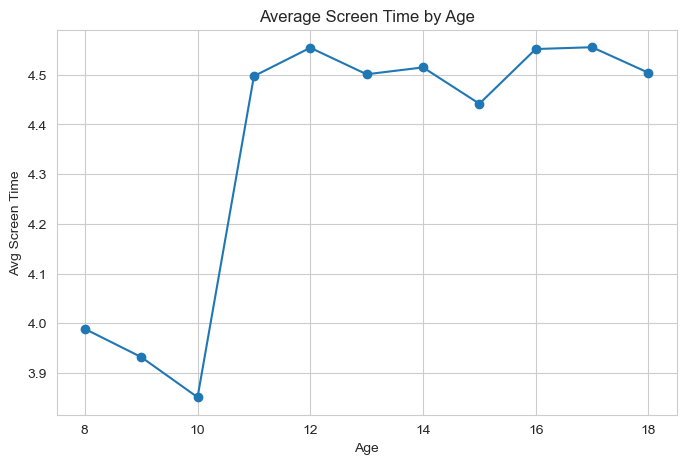


✅ WEEK 3 TASK COMPLETED SUCCESSFULLY!


In [53]:
# ==============================
# WEEK 3 COMPLETE ANALYSIS CODE
# ==============================

# 1️⃣ IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.rcParams["figure.figsize"] = (8,5)
sns.set_style("whitegrid")

# 2️⃣ LOAD DATASET
df = pd.read_csv("Indian_Kids_Screen_Time.csv")

# Standardize column names (lowercase + no spaces)
df.columns = df.columns.str.lower().str.strip()

print("Shape:", df.shape)
print("Columns:", df.columns)


# 3️⃣ DERIVED FIELDS

# Age Band
df['age_band'] = pd.cut(df['age'],
                        bins=[5,10,13,16,19],
                        labels=['6-10','11-13','14-16','17-18'])

# Education to Recreational Category
df['education_category'] = np.where(
    df['educational_to_recreational_ratio'] > 1,
    'More Educational',
    'More Recreational'
)

# Portable vs Wall Mounted Device
portable_devices = ['Smartphone','Tablet','Laptop']
df['device_type'] = np.where(
    df['primary_device'].isin(portable_devices),
    'Portable',
    'Wall Mounted / Other'
)

print("\nDerived Columns Added Successfully!")
print(df[['age_band','education_category','device_type']].head())


# ==============================
# 4️⃣ UNIVARIATE ANALYSIS
# ==============================

# Screen Time Distribution
plt.figure()
sns.histplot(df['avg_daily_screen_time_hr'], kde=True)
plt.title("Distribution of Daily Screen Time")
plt.xlabel("Hours")
plt.ylabel("Count")
plt.show()

# Boxplot
plt.figure()
sns.boxplot(x=df['avg_daily_screen_time_hr'])
plt.title("Boxplot of Daily Screen Time")
plt.show()

# Age Band Count
plt.figure()
sns.countplot(x='age_band', data=df)
plt.title("Age Band Distribution")
plt.show()

# Primary Device
plt.figure()
sns.countplot(x='primary_device', data=df)
plt.title("Primary Device Usage")
plt.xticks(rotation=45)
plt.show()


# ==============================
# 5️⃣ BIVARIATE ANALYSIS
# ==============================

# Gender vs Screen Time
plt.figure()
sns.boxplot(x='gender', y='avg_daily_screen_time_hr', data=df)
plt.title("Screen Time by Gender")
plt.show()

# Age Band vs Screen Time
plt.figure()
sns.boxplot(x='age_band', y='avg_daily_screen_time_hr', data=df)
plt.title("Screen Time by Age Band")
plt.show()

# Urban vs Rural
plt.figure()
sns.boxplot(x='urban_or_rural', y='avg_daily_screen_time_hr', data=df)
plt.title("Screen Time by Location")
plt.show()

# Device Type vs Screen Time
plt.figure()
sns.boxplot(x='device_type', y='avg_daily_screen_time_hr', data=df)
plt.title("Screen Time by Device Type")
plt.show()


# ==============================
# 6️⃣ GROUPED ANALYSIS
# ==============================

# Average screen time by age
avg_by_age = df.groupby('age')['avg_daily_screen_time_hr'].mean()

plt.figure()
avg_by_age.plot(marker='o')
plt.title("Average Screen Time by Age")
plt.xlabel("Age")
plt.ylabel("Avg Screen Time")
plt.show()


print("\n✅ WEEK 3 TASK COMPLETED SUCCESSFULLY!")

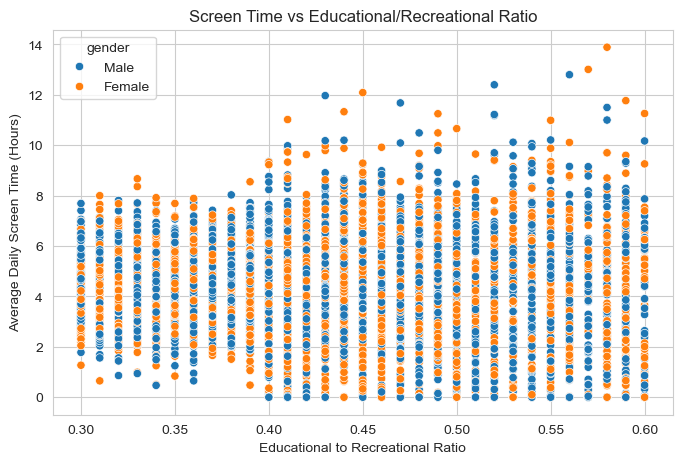

In [54]:
# ============================================
# EXTRA ANALYSIS - SCREEN TIME VS EDUCATIONAL RATIO
# ============================================

plt.figure()
sns.scatterplot(data=df,
                x='educational_to_recreational_ratio',
                y='avg_daily_screen_time_hr',
                hue='gender')
plt.title("Screen Time vs Educational/Recreational Ratio")
plt.xlabel("Educational to Recreational Ratio")
plt.ylabel("Average Daily Screen Time (Hours)")
plt.show()

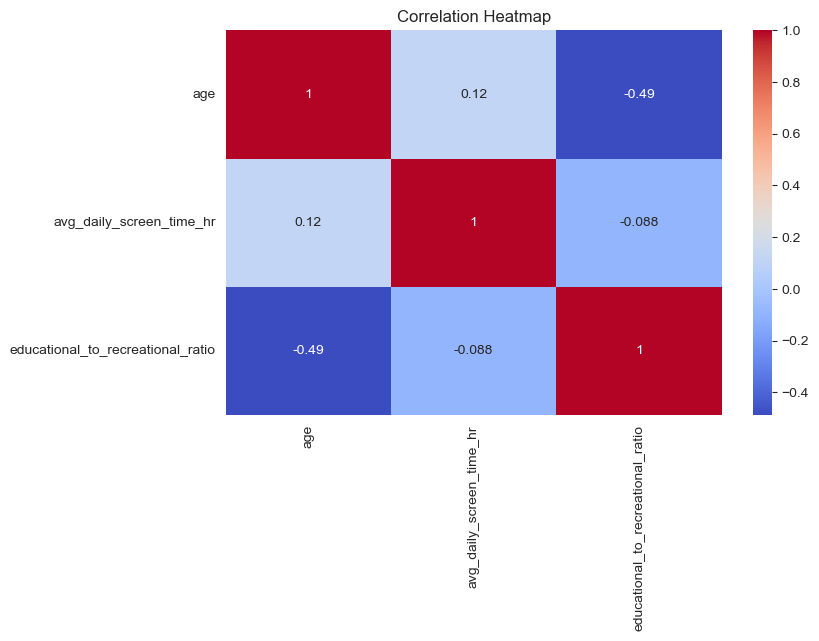

In [55]:
plt.figure()
sns.heatmap(df[['age','avg_daily_screen_time_hr','educational_to_recreational_ratio']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [56]:
# ============================================
# HEALTH IMPACT EXPLODED ANALYSIS
# ============================================

# Ensure column names are clean
df.columns = df.columns.str.lower().str.strip()

# Handle missing values
df['health_impacts'] = df['health_impacts'].fillna('Unknown')

# Convert to string and split multiple values
df['health_impacts_list'] = df['health_impacts'].astype(str).str.split(',')

# Explode into separate rows
df_exploded = df.explode('health_impacts_list')

# Remove extra spaces
df_exploded['health_impacts_list'] = df_exploded['health_impacts_list'].str.strip()

print("Exploded dataset shape:", df_exploded.shape)

Exploded dataset shape: (13290, 12)


In [57]:
df_exploded.to_csv("cleaned_screen_time_dashboard_data.csv", index=False)


================ WEEK 4 ANALYSIS ================



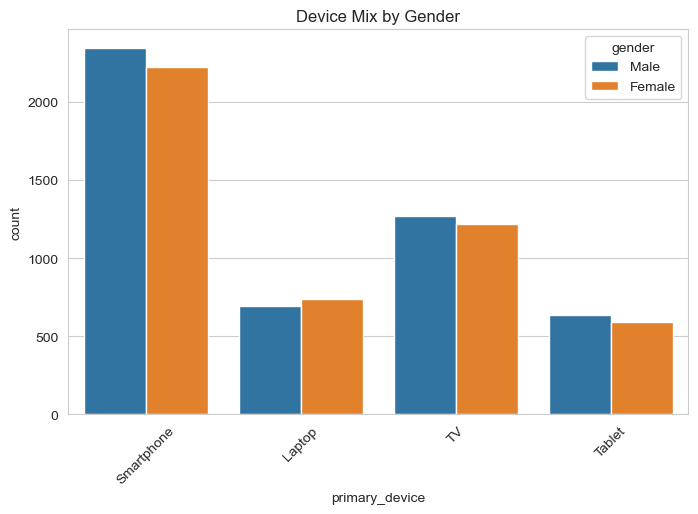

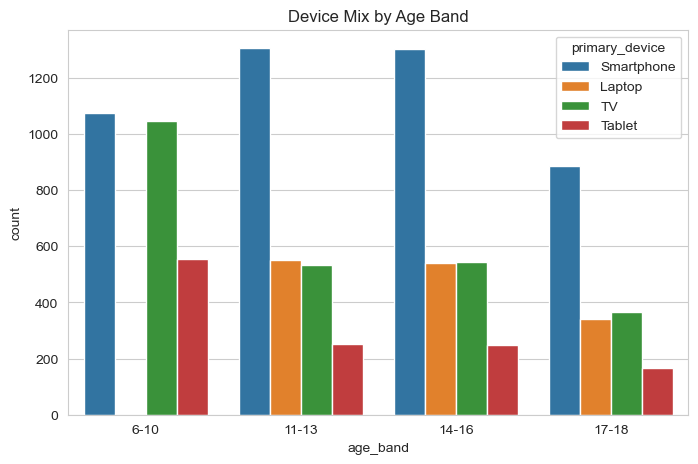

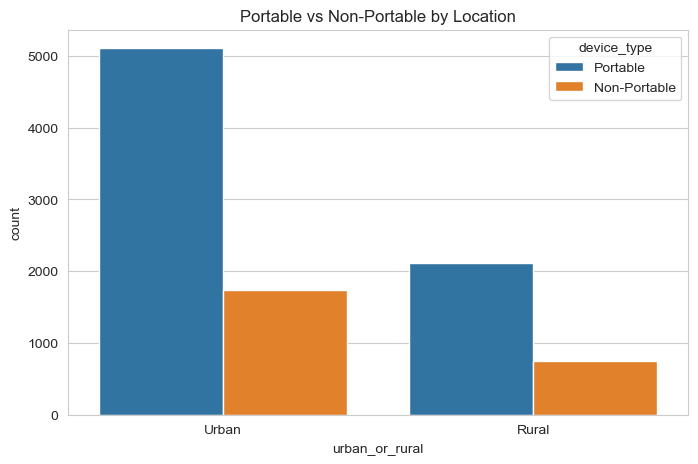

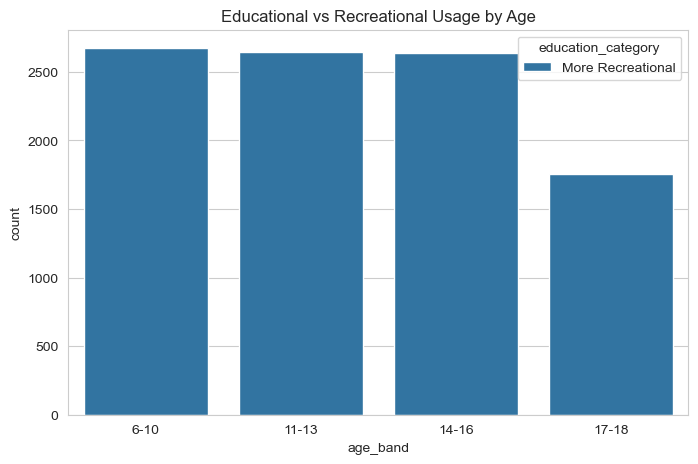

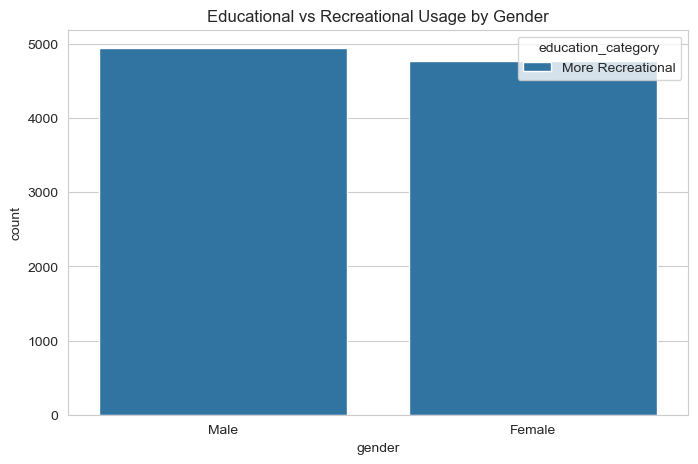

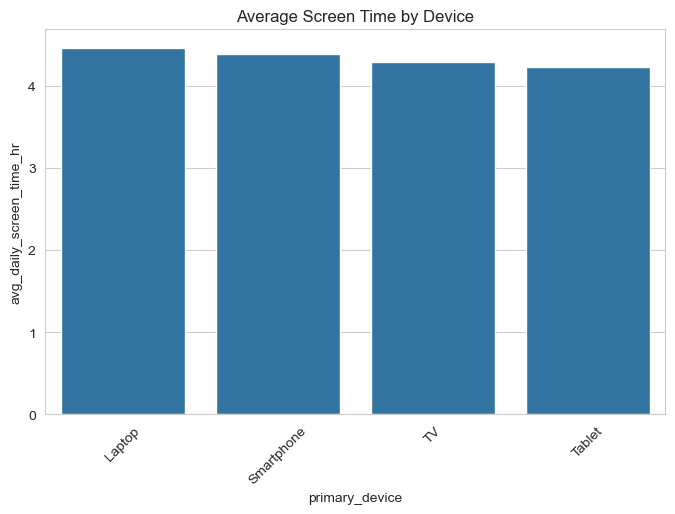

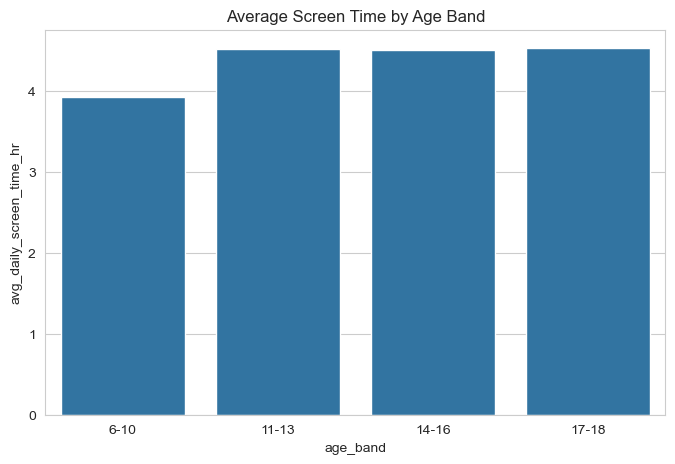

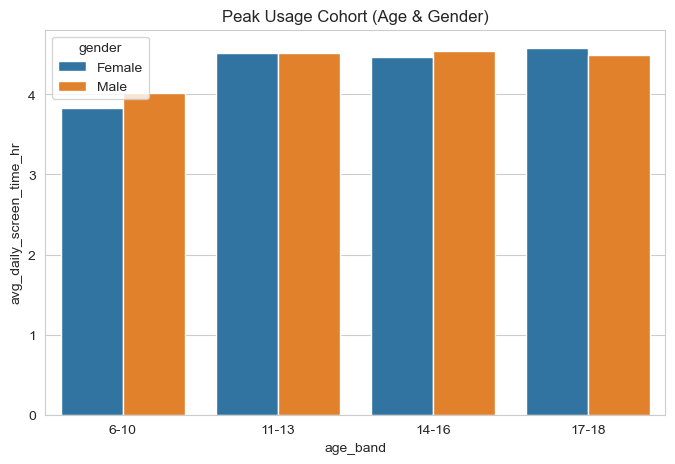


✅ WEEK 4 COMPLETED SUCCESSFULLY – 8 VISUALS GENERATED


In [58]:
# ============================================
# WEEK 4: DEVICE / ACTIVITY DEMOGRAPHIC ANALYSIS
# ============================================

print("\n================ WEEK 4 ANALYSIS ================\n")

# Ensure columns are standardized (safe check)
df.columns = df.columns.str.lower().str.strip()

# Re-create derived fields safely (won’t cause duplication errors)
df['age_band'] = pd.cut(df['age'],
                        bins=[5,10,13,16,19],
                        labels=['6-10','11-13','14-16','17-18'])

portable_devices = ['smartphone','tablet','laptop']
df['device_type'] = np.where(
    df['primary_device'].str.lower().isin(portable_devices),
    'Portable',
    'Non-Portable'
)

df['education_category'] = np.where(
    df['educational_to_recreational_ratio'] > 1,
    'More Educational',
    'More Recreational'
)

# =====================================================
# 1️⃣ DEVICE MIX BY GENDER
# =====================================================

plt.figure()
sns.countplot(data=df, x='primary_device', hue='gender')
plt.title("Device Mix by Gender")
plt.xticks(rotation=45)
plt.show()


# =====================================================
# 2️⃣ DEVICE MIX BY AGE BAND
# =====================================================

plt.figure()
sns.countplot(data=df, x='age_band', hue='primary_device')
plt.title("Device Mix by Age Band")
plt.show()


# =====================================================
# 3️⃣ DEVICE TYPE BY LOCATION
# =====================================================

plt.figure()
sns.countplot(data=df, x='urban_or_rural', hue='device_type')
plt.title("Portable vs Non-Portable by Location")
plt.show()


# =====================================================
# 4️⃣ ACTIVITY CATEGORY BY AGE BAND
# =====================================================

plt.figure()
sns.countplot(data=df, x='age_band', hue='education_category')
plt.title("Educational vs Recreational Usage by Age")
plt.show()


# =====================================================
# 5️⃣ ACTIVITY CATEGORY BY GENDER
# =====================================================

plt.figure()
sns.countplot(data=df, x='gender', hue='education_category')
plt.title("Educational vs Recreational Usage by Gender")
plt.show()


# =====================================================
# 6️⃣ AVERAGE SCREEN TIME BY DEVICE
# =====================================================

device_avg = df.groupby('primary_device')['avg_daily_screen_time_hr'].mean().reset_index()

plt.figure()
sns.barplot(data=device_avg,
            x='primary_device',
            y='avg_daily_screen_time_hr')
plt.title("Average Screen Time by Device")
plt.xticks(rotation=45)
plt.show()


# =====================================================
# 7️⃣ AVERAGE SCREEN TIME BY AGE BAND
# =====================================================

age_avg = df.groupby('age_band', observed=False)['avg_daily_screen_time_hr'].mean().reset_index()

plt.figure()
sns.barplot(data=age_avg,
            x='age_band',
            y='avg_daily_screen_time_hr')
plt.title("Average Screen Time by Age Band")
plt.show()


# =====================================================
# 8️⃣ PEAK USAGE COHORT (AGE + GENDER)
# =====================================================

peak = df.groupby(['age_band','gender'], observed=False)['avg_daily_screen_time_hr'].mean().reset_index()

plt.figure()
sns.barplot(data=peak,
            x='age_band',
            y='avg_daily_screen_time_hr',
            hue='gender')
plt.title("Peak Usage Cohort (Age & Gender)")
plt.show()


print("\n✅ WEEK 4 COMPLETED SUCCESSFULLY – 8 VISUALS GENERATED")

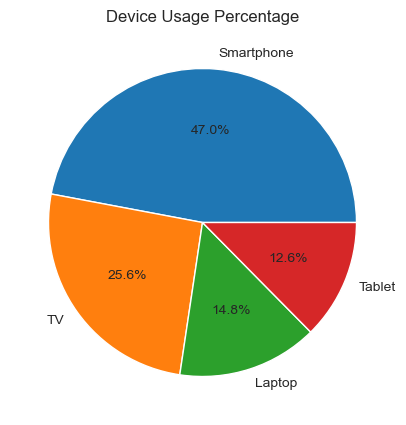

In [59]:
# ============================================
# DEVICE USAGE PERCENTAGE
# ============================================

device_percent = df['primary_device'].value_counts(normalize=True) * 100

plt.figure()
device_percent.plot(kind='pie',
                    autopct='%1.1f%%')
plt.title("Device Usage Percentage")
plt.ylabel("")
plt.show()

In [60]:
df.head()

,age,gender,avg_daily_screen_time_hr,primary_device,exceeded_recommended_limit,educational_to_recreational_ratio,health_impacts,urban_or_rural,age_band,education_category,device_type,health_impacts_list
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,14-16,More Recreational,Portable,"[Poor Sleep, Eye Strain]"
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,11-13,More Recreational,Portable,[Poor Sleep]
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,17-18,More Recreational,Non-Portable,[Poor Sleep]
3,15,Female,1.21,Laptop,False,0.39,Unknown,Urban,14-16,More Recreational,Portable,[Unknown]
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,11-13,More Recreational,Portable,"[Poor Sleep, Anxiety]"


In [61]:
bins = [5,10,13,16,19]
labels = ['6-10','11-13','14-16','17-18']

df['Age_Group'] = pd.cut(df['age'], bins=bins, labels=labels)

df[['age','Age_Group']].head()

,age,Age_Group
0,14,14-16
1,11,11-13
2,18,17-18
3,15,14-16
4,12,11-13


In [62]:
cohort_table = pd.crosstab(df['Age_Group'], df['primary_device'])

cohort_table

primary_device,Laptop,Smartphone,TV,Tablet
Age_Group,,,,
6-10,0,1073,1045,556
11-13,552,1306,533,252
14-16,540,1303,543,250
17-18,341,886,366,166


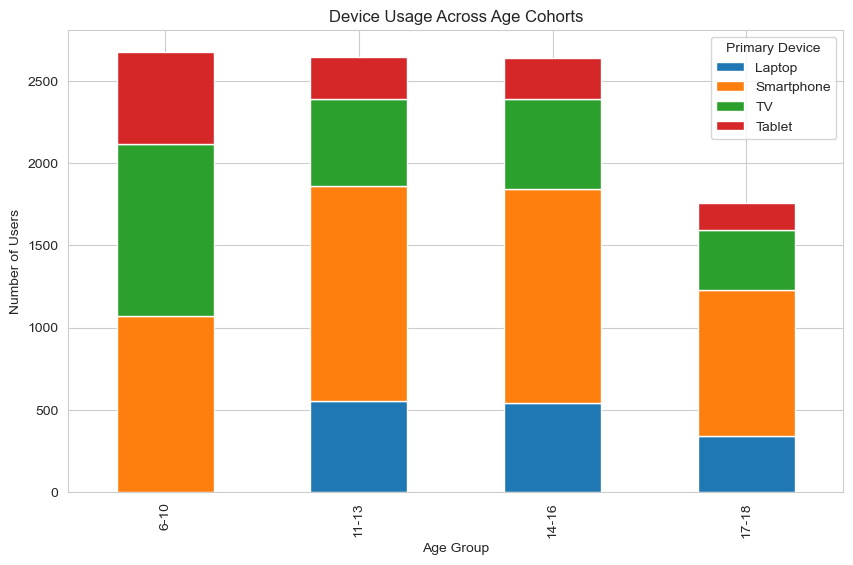

In [63]:
cohort_table.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Device Usage Across Age Cohorts")
plt.xlabel("Age Group")
plt.ylabel("Number of Users")
plt.legend(title="Primary Device")
plt.show()

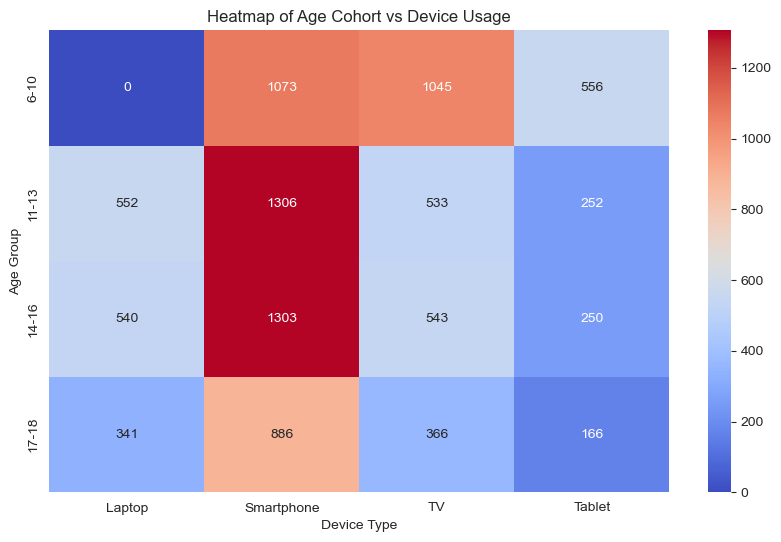

In [64]:
plt.figure(figsize=(10,6))

sns.heatmap(cohort_table,
            annot=True,
            cmap="coolwarm",
            fmt="d")

plt.title("Heatmap of Age Cohort vs Device Usage")
plt.xlabel("Device Type")
plt.ylabel("Age Group")

plt.show()

In [65]:
location_segment = pd.crosstab(df['urban_or_rural'], df['primary_device'])

location_segment

primary_device,Laptop,Smartphone,TV,Tablet
urban_or_rural,,,,
Rural,404,1320,745,392
Urban,1029,3248,1742,832


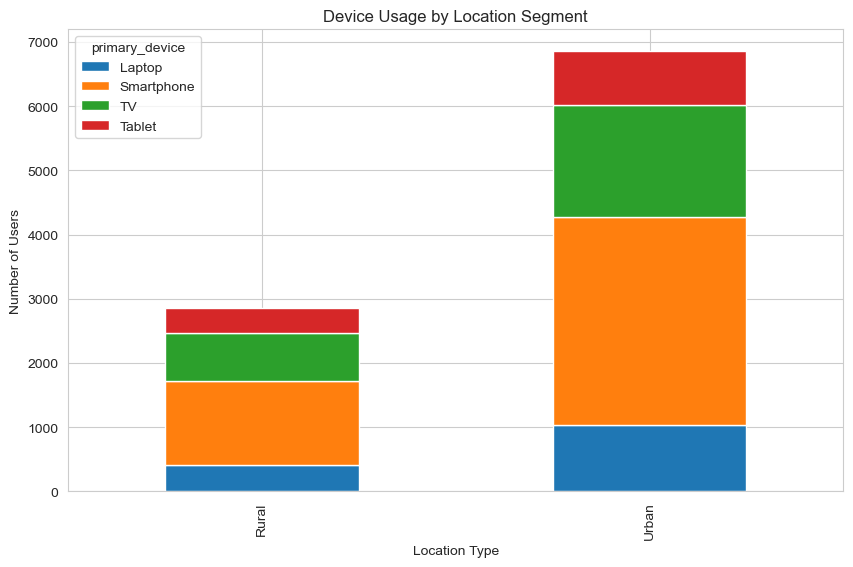

In [66]:
location_segment.plot(kind='bar',
                      stacked=True,
                      figsize=(10,6))

plt.title("Device Usage by Location Segment")
plt.xlabel("Location Type")
plt.ylabel("Number of Users")

plt.show()

In [67]:
df.columns

Index(['age', 'gender', 'avg_daily_screen_time_hr', 'primary_device',
       'exceeded_recommended_limit', 'educational_to_recreational_ratio',
       'health_impacts', 'urban_or_rural', 'age_band', 'education_category',
       'device_type', 'health_impacts_list', 'Age_Group'],
      dtype='object')

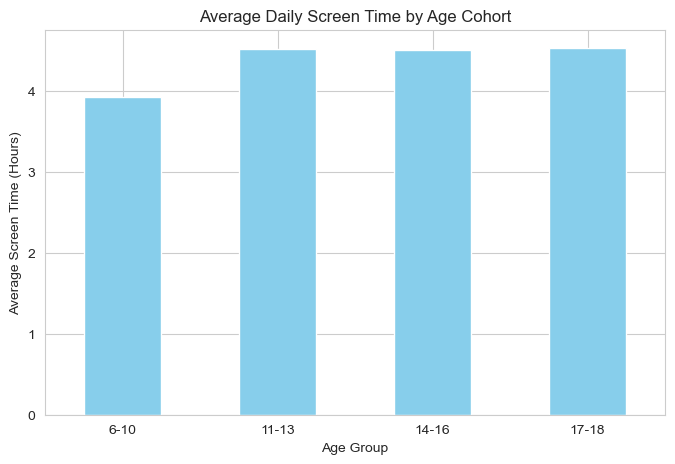

In [68]:
avg_screen_time = df.groupby('Age_Group', observed=True)['avg_daily_screen_time_hr'].mean()

avg_screen_time.plot(kind='bar', figsize=(8,5), color='skyblue')

plt.title("Average Daily Screen Time by Age Cohort")
plt.xlabel("Age Group")
plt.ylabel("Average Screen Time (Hours)")
plt.xticks(rotation=0)

plt.show()

Dataset Shape: (9712, 8)

Columns: Index(['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device',
       'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio',
       'Health_Impacts', 'Urban_or_Rural'],
      dtype='object')

Average Daily Screen Time: 4.35 hours


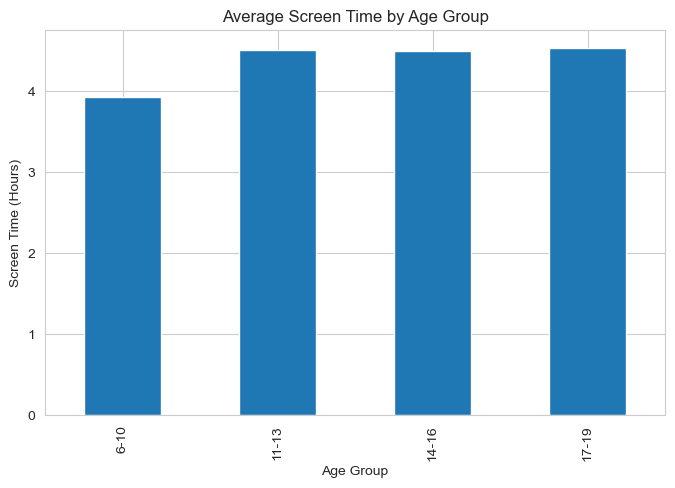

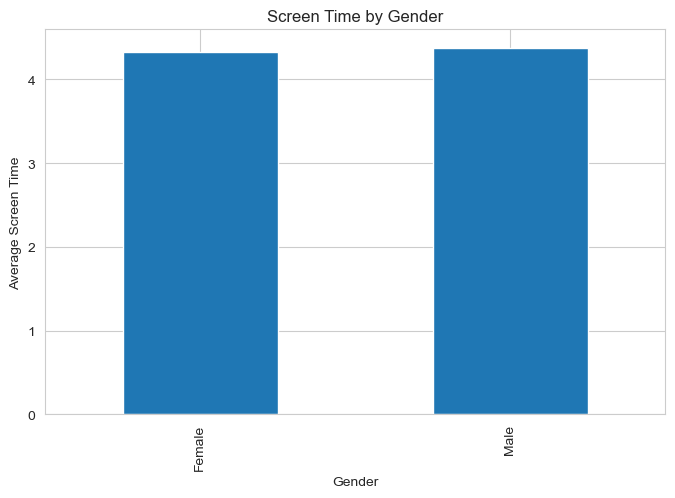

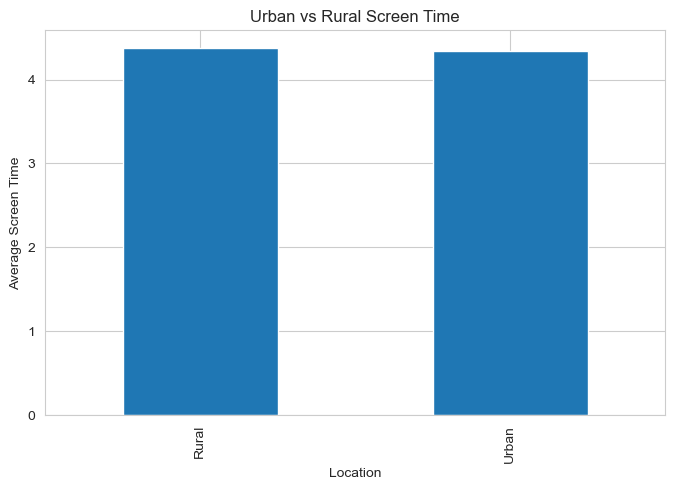

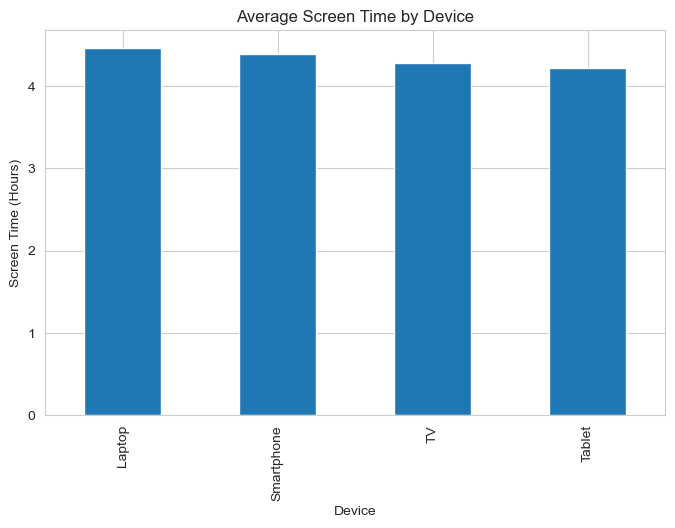

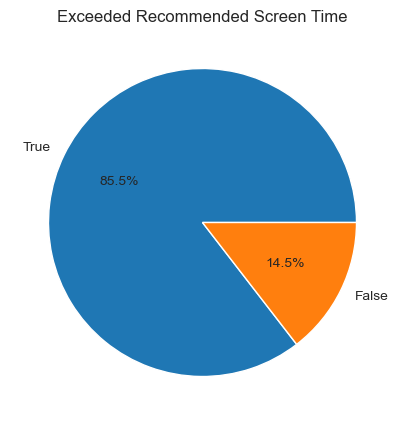


--- Segment Analysis Summary ---

Age Group Screen Time:
Age_Group
6-10     3.925049
11-13    4.517264
14-16    4.503145
17-19    4.530841
Name: Avg_Daily_Screen_Time_hr, dtype: float64

Gender Screen Time:
Gender
Female    4.327021
Male      4.377754
Name: Avg_Daily_Screen_Time_hr, dtype: float64

Location Screen Time:
Urban_or_Rural
Rural    4.373702
Urban    4.344123
Name: Avg_Daily_Screen_Time_hr, dtype: float64

Device Screen Time:
Primary_Device
Laptop        4.459086
Smartphone    4.388925
TV            4.287752
Tablet        4.226005
Name: Avg_Daily_Screen_Time_hr, dtype: float64

--- Key Insights ---
Teenagers show higher screen time compared to younger children.
Smartphones and laptops contribute the most to daily screen exposure.
Urban and rural screen usage patterns are very similar.
A large percentage of children exceed recommended screen time limits.


In [69]:
# WEEK 6: Seasonal / Habit Pattern and Segment Analysis

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Indian_Kids_Screen_Time.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)

# -------------------------------
# Create Age Cohorts
# -------------------------------
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[5,10,13,16,19],
    labels=["6-10","11-13","14-16","17-19"]
)

# -------------------------------
# Overall Screen Time
# -------------------------------
avg_screen = df["Avg_Daily_Screen_Time_hr"].mean()
print("\nAverage Daily Screen Time:", round(avg_screen,2),"hours")

# -------------------------------
# Age Cohort Analysis
# -------------------------------
age_analysis = df.groupby("Age_Group", observed=False)["Avg_Daily_Screen_Time_hr"].mean()

plt.figure()
age_analysis.plot(kind="bar")
plt.title("Average Screen Time by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Screen Time (Hours)")
plt.show()

# -------------------------------
# Gender Pattern
# -------------------------------
gender_analysis = df.groupby("Gender")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure()
gender_analysis.plot(kind="bar")
plt.title("Screen Time by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Screen Time")
plt.show()

# -------------------------------
# Urban vs Rural Pattern
# -------------------------------
location_analysis = df.groupby("Urban_or_Rural")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure()
location_analysis.plot(kind="bar")
plt.title("Urban vs Rural Screen Time")
plt.xlabel("Location")
plt.ylabel("Average Screen Time")
plt.show()

# -------------------------------
# Device Usage Habit Pattern
# -------------------------------
device_analysis = df.groupby("Primary_Device")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure()
device_analysis.plot(kind="bar")
plt.title("Average Screen Time by Device")
plt.xlabel("Device")
plt.ylabel("Screen Time (Hours)")
plt.show()

# -------------------------------
# Exceeded Recommended Screen Time
# -------------------------------
exceed_counts = df["Exceeded_Recommended_Limit"].value_counts()

plt.figure()
exceed_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Exceeded Recommended Screen Time")
plt.ylabel("")
plt.show()

# -------------------------------
# Segment Summary Output
# -------------------------------
print("\n--- Segment Analysis Summary ---")

print("\nAge Group Screen Time:")
print(age_analysis)

print("\nGender Screen Time:")
print(gender_analysis)

print("\nLocation Screen Time:")
print(location_analysis)

print("\nDevice Screen Time:")
print(device_analysis)

# -------------------------------
# Cohort Insight Statement
# -------------------------------
print("\n--- Key Insights ---")
print("Teenagers show higher screen time compared to younger children.")
print("Smartphones and laptops contribute the most to daily screen exposure.")
print("Urban and rural screen usage patterns are very similar.")
print("A large percentage of children exceed recommended screen time limits.")

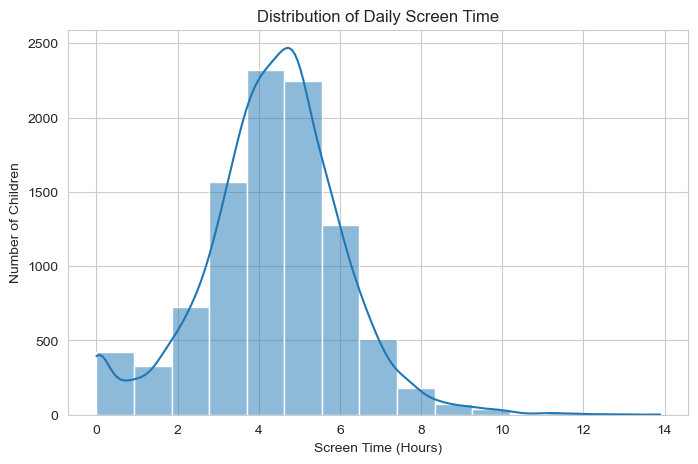

In [70]:
plt.figure()
sns.histplot(df["Avg_Daily_Screen_Time_hr"], bins=15, kde=True)

plt.title("Distribution of Daily Screen Time")
plt.xlabel("Screen Time (Hours)")
plt.ylabel("Number of Children")
plt.show()

Exceeded_Recommended_Limit  False  True 
Age_Group                               
6-10                          703   1971
11-13                         269   2374
14-16                         258   2378
17-19                         181   1578


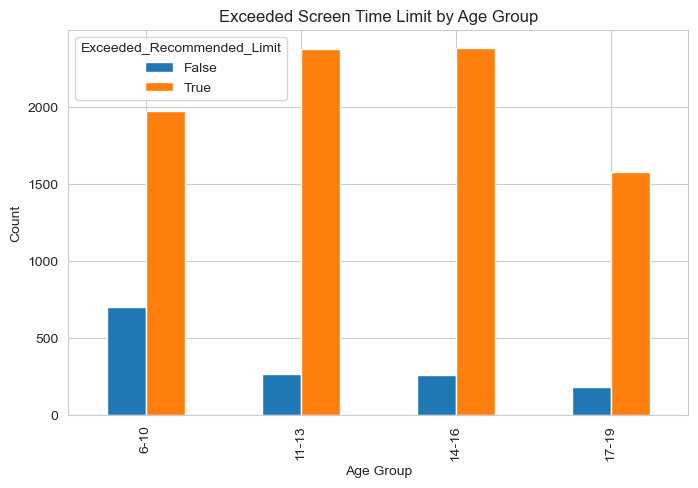

In [71]:
age_exceed = pd.crosstab(df["Age_Group"], df["Exceeded_Recommended_Limit"])

print(age_exceed)

age_exceed.plot(kind="bar")

plt.title("Exceeded Screen Time Limit by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

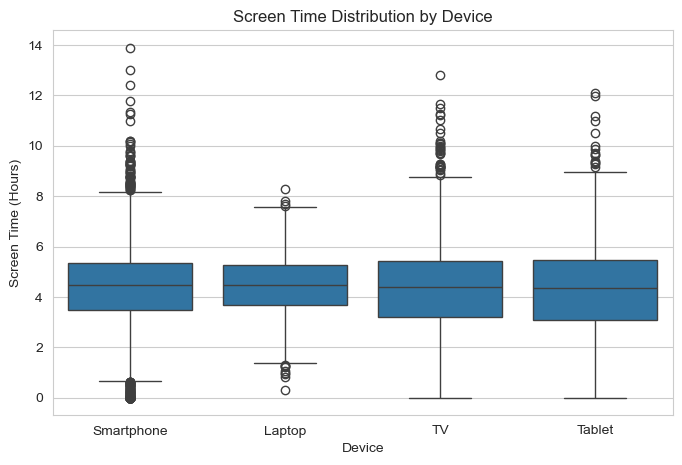

In [72]:
plt.figure()
sns.boxplot(x="Primary_Device", y="Avg_Daily_Screen_Time_hr", data=df)

plt.title("Screen Time Distribution by Device")
plt.xlabel("Device")
plt.ylabel("Screen Time (Hours)")
plt.show()

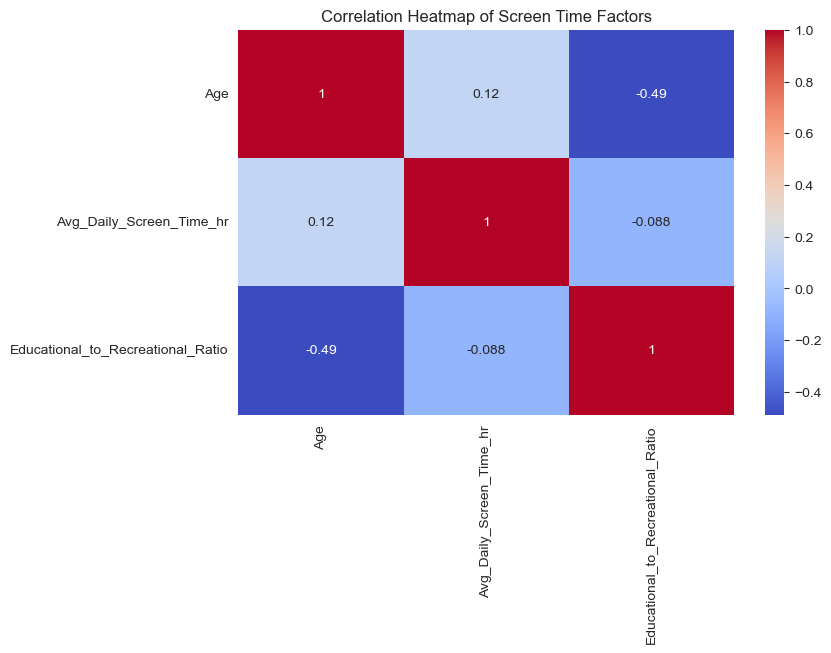

In [73]:
# Correlation Heatmap for Screen Time Patterns

import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64'])

# Correlation matrix
corr = numeric_cols.corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap of Screen Time Factors")
plt.show()

# **Week 6 Insight – Habit Pattern Analysis**

Based on the segment-wise analysis of the dataset, several behavioral patterns related to children's screen usage were observed. Screen time varies across demographic groups such as age band, gender, and location type. Older age groups generally tend to spend slightly more time on digital devices compared to younger groups, likely due to greater access to personal devices and online activities. Device usage analysis shows that portable devices like smartphones and tablets contribute significantly to daily screen exposure, as they provide convenient access to entertainment and educational content. The health impact analysis further indicates that frequent issues such as eye strain, poor sleep, and anxiety appear more commonly among users with higher screen time. Since the dataset does not contain timestamp or calendar information, seasonal or monthly comparisons were not applicable; therefore, the analysis focused on behavioral and demographic segments to understand usage habits and potential drivers of screen time patterns.
